# Chapter 8. ML and DL for EEG

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset

In [ ]:
# load the Excel file as a DataFrame
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EEG_dataset/EEG.csv")
display(eeg_data.head())

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


**Make Labeling**

In [ ]:

label_mapping = {
    "NEGATIVE": 0,
    "NEUTRAL": 1,
    "POSITIVE": 2
}

eeg_data["label"] = eeg_data["label"].map(label_mapping)

display(eeg_data.head())

,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,0
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,1
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,2
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,2
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,1


Scaling data

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Load data
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EEG_dataset/EEG.csv")

# Encode labels to 0, 1, 2
label_mapping = {"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
eeg_data["label"] = eeg_data["label"].map(label_mapping)

# Separate features and labels
X = eeg_data.drop(columns=["label"])  # Features only
y = eeg_data["label"]                 # Labels only

# Scale features with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame and recombine with label
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
eeg_data_scaled = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)

# Check result
display(eeg_data_scaled.head())


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,0.180454,0.923225,0.376456,0.444898,0.565814,0.353339,0.498850,0.535578,0.371486,0.557823,...,0.535431,0.262939,0.262939,0.535431,0.403846,0.679663,0.163852,0.163852,0.679663,0
1,0.246647,0.941139,0.614347,0.474636,0.557674,0.362177,0.501328,0.542980,0.374692,0.549829,...,0.508900,0.241825,0.241825,0.508900,0.573504,0.533493,0.223368,0.223368,0.533493,1
2,0.192171,0.917466,0.339669,0.448105,0.559767,0.480484,0.504609,0.577769,0.530616,0.556700,...,0.784014,0.135908,0.135908,0.784014,0.381624,0.680190,0.170242,0.170242,0.680190,2
3,0.208596,0.931542,0.507051,0.457143,0.561163,0.350671,0.497492,0.545347,0.371920,0.552688,...,0.691610,0.130893,0.130893,0.691610,0.552137,0.525606,0.242141,0.242141,0.525606,2
4,0.245278,0.929623,0.622440,0.479009,0.561628,0.407742,0.486738,0.543052,0.442754,0.560201,...,0.528912,0.271866,0.271866,0.528912,0.546581,0.522866,0.248699,0.248699,0.522866,1


**Mix Data**

In [ ]:
from sklearn.utils import shuffle

# Shuffle the entire DataFrame
eeg_data_mixed = shuffle(eeg_data_scaled, random_state=42).reset_index(drop=True)

# Check the result
display(eeg_data_mixed.head())


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,0.251574,0.941779,0.613611,0.479883,0.563023,0.347935,0.498574,0.543414,0.366638,0.558666,...,0.527098,0.254819,0.254819,0.527098,0.565385,0.528635,0.235682,0.235682,0.528635,1
1,0.247468,0.929623,0.614715,0.478717,0.558605,0.347597,0.498011,0.540753,0.362428,0.554187,...,0.528401,0.256715,0.256715,0.528401,0.546581,0.539989,0.240324,0.240324,0.539989,1
2,0.179387,0.923225,0.388105,0.431778,0.563953,0.396452,0.508887,0.554183,0.358442,0.558696,...,0.525533,0.249930,0.249930,0.525533,0.410256,0.648051,0.166591,0.166591,0.648051,0
3,0.199015,0.932821,0.513795,0.434111,0.570698,0.361194,0.492402,0.543526,0.384312,0.551745,...,0.713719,0.163992,0.163992,0.713719,0.560256,0.533783,0.258421,0.258421,0.533783,0
4,0.131399,0.641075,0.603250,0.327697,0.446744,0.359581,0.507188,0.539454,0.371920,0.558295,...,0.523141,0.285757,0.285757,0.523141,0.458718,0.533498,0.227887,0.227887,0.533498,2


fhjhgjgj

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


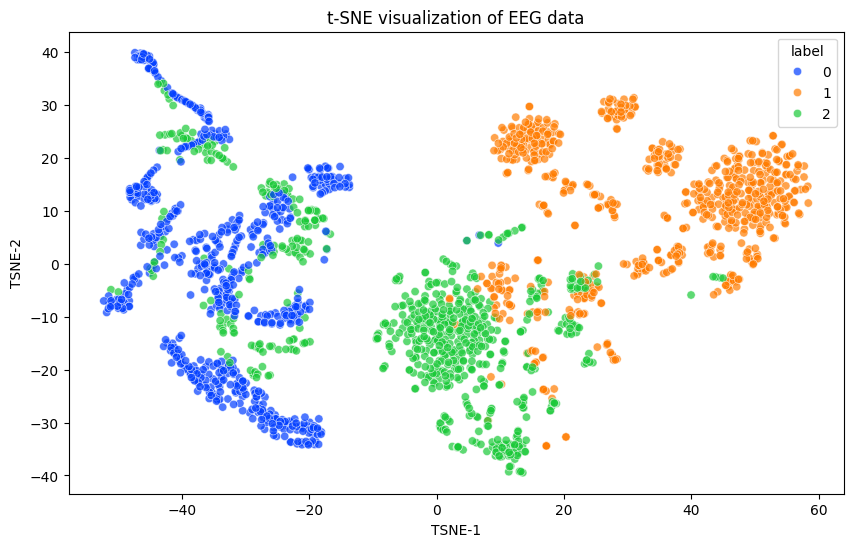

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Assuming eeg_data_mixed is your mixed DataFrame
# Separate features and labels
X = eeg_data_mixed.drop("label", axis=1)  # features
y = eeg_data_mixed["label"]               # numeric labels: 0,1,2

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for visualization
tsne_df = pd.DataFrame()
tsne_df["TSNE-1"] = X_tsne[:,0]
tsne_df["TSNE-2"] = X_tsne[:,1]
tsne_df["label"] = y

# Plot t-SNE
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="TSNE-1", y="TSNE-2",
    hue="label",
    palette=sns.color_palette("bright", 3),
    data=tsne_df,
    legend="full",
    alpha=0.7
)
plt.title("t-SNE visualization of EEG data")
plt.show()


fgdfgf

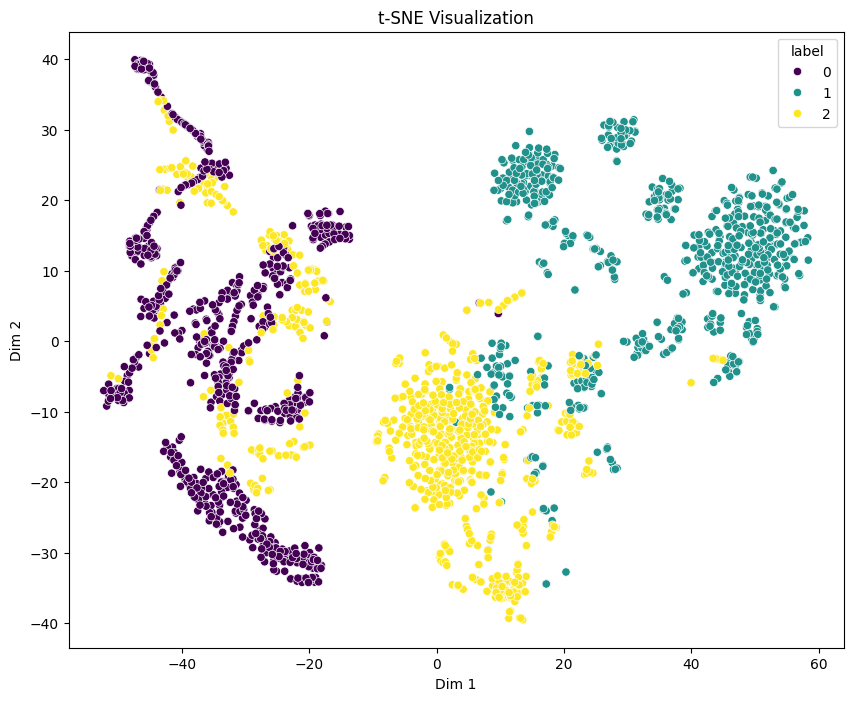

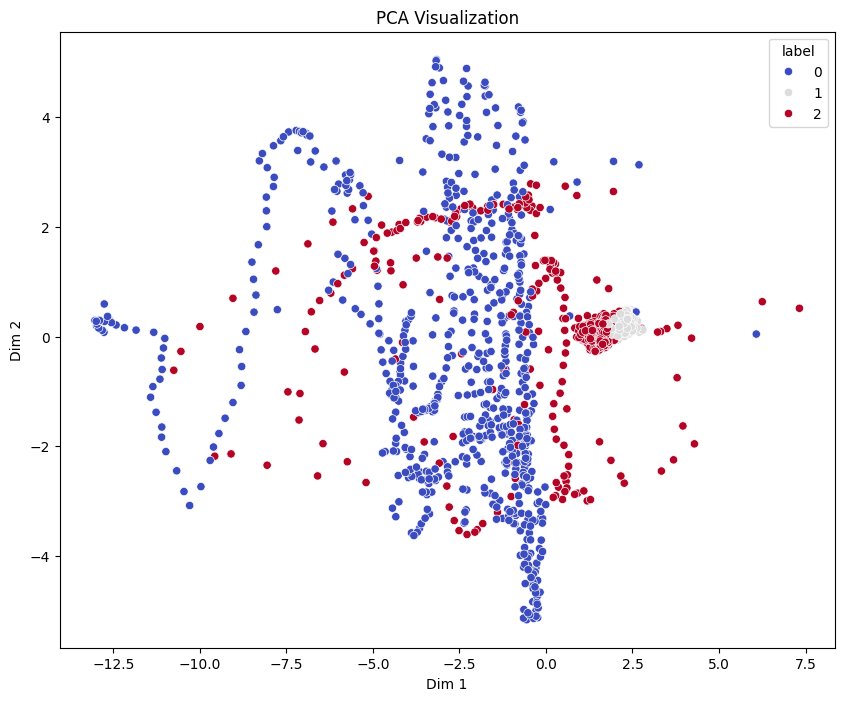

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


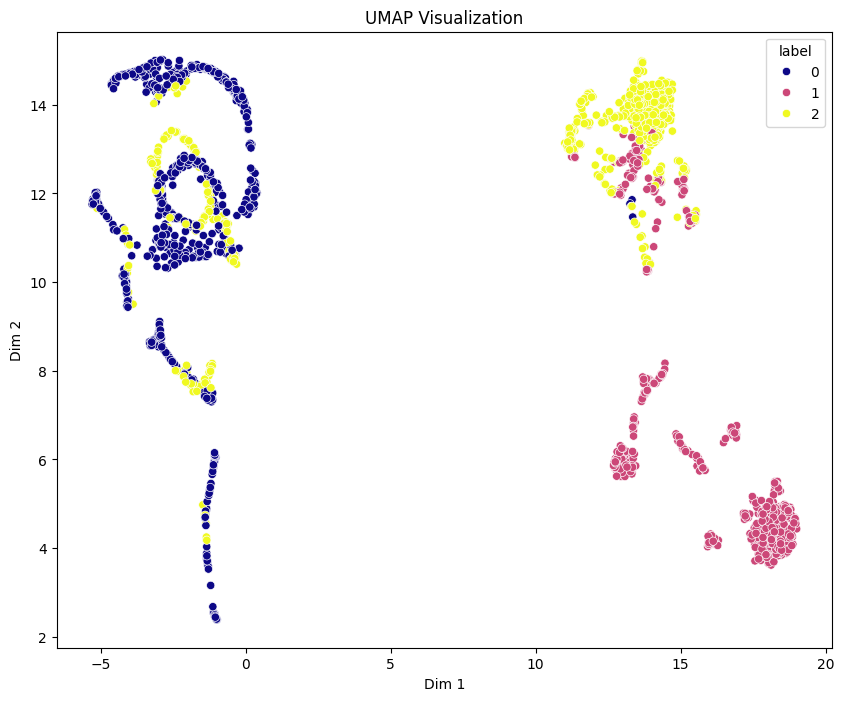

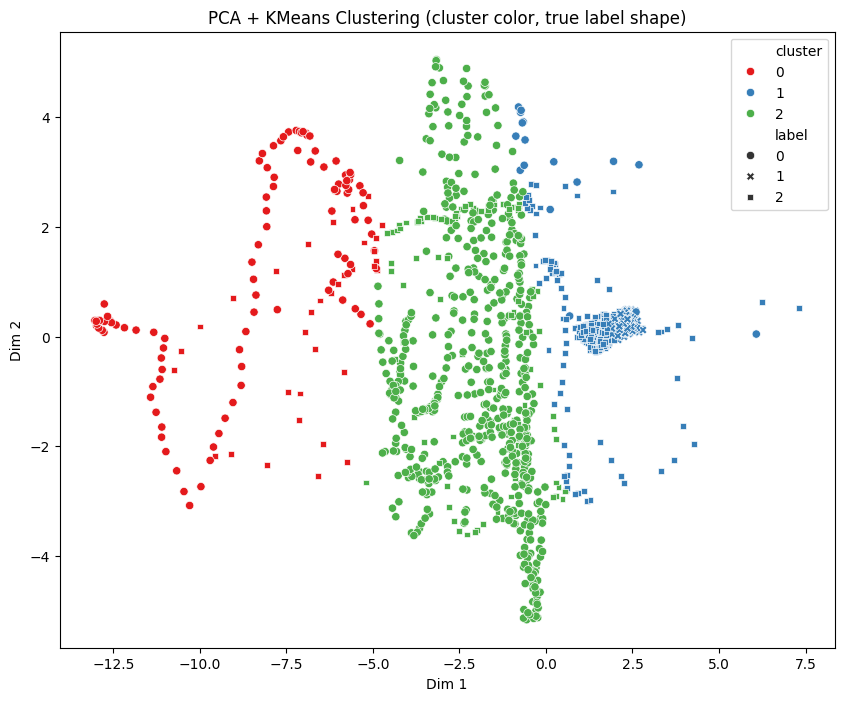

In [ ]:
# =========================
# EEG Data Visualization
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap
from sklearn.cluster import KMeans

# -------------------------
# 1. Load data
# -------------------------
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EEG_dataset/EEG.csv")

# Map labels to 0, 1, 2
label_map = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
eeg_data['label'] = eeg_data['label'].map(label_map)

# -------------------------
# 2. Scale features (exclude label)
# -------------------------
features = eeg_data.drop('label', axis=1)
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# -------------------------
# 3. Shuffle / mix data
# -------------------------
data_scaled = pd.DataFrame(features_scaled, columns=features.columns)
data_scaled['label'] = eeg_data['label'].values
data_scaled = data_scaled.sample(frac=1, random_state=42).reset_index(drop=True)

# Features and labels
X = data_scaled.drop('label', axis=1)
y = data_scaled['label']

# -------------------------
# 4a. t-SNE Visualization
# -------------------------
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(X)
tsne_df = pd.DataFrame(tsne_results, columns=['Dim 1', 'Dim 2'])
tsne_df['label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='label', data=tsne_df, palette='viridis')
plt.title("t-SNE Visualization")
plt.show()

# -------------------------
# 4b. PCA Visualization
# -------------------------
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X)
pca_df = pd.DataFrame(pca_results, columns=['Dim 1', 'Dim 2'])
pca_df['label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='label', data=pca_df, palette='coolwarm')
plt.title("PCA Visualization")
plt.show()

# -------------------------
# 4c. UMAP Visualization
# -------------------------
umap_reducer = umap.UMAP(n_components=2, random_state=42)
umap_results = umap_reducer.fit_transform(X)
umap_df = pd.DataFrame(umap_results, columns=['Dim 1', 'Dim 2'])
umap_df['label'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='label', data=umap_df, palette='plasma')
plt.title("UMAP Visualization")
plt.show()

# -------------------------
# 5. Optional: KMeans clustering on PCA
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pca_results)
pca_df['cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Dim 1', y='Dim 2', hue='cluster', data=pca_df, palette='Set1', style='label')
plt.title("PCA + KMeans Clustering (cluster color, true label shape)")
plt.show()


**Machine Learning**

In [ ]:
# =========================
# EEG Random Forest Classification
# =========================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# 1. Load EEG data
# -------------------------
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EEG_dataset/EEG.csv")

# Map labels to 0, 1, 2
label_map = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
eeg_data['label'] = eeg_data['label'].map(label_map)

# -------------------------
# 2. Scale features (exclude label)
# -------------------------
features = eeg_data.drop('label', axis=1)
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# Create DataFrame with scaled features
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled_df['label'] = eeg_data['label'].values

# -------------------------
# 3. Shuffle / mix data
# -------------------------
features_scaled_df = features_scaled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------
# 4. Separate features and target
# -------------------------
X = features_scaled_df.drop('label', axis=1)
y = features_scaled_df['label']

# -------------------------
# 5. Train-test split (70% train, 30% test)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------
# 6. Initialize Random Forest
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=None,     # allow trees to expand fully
    random_state=42
)

# -------------------------
# 7. Train the model
# -------------------------
rf_model.fit(X_train, y_train)

# -------------------------
# 8. Make predictions
# -------------------------
y_pred = rf_model.predict(X_test)

# -------------------------
# 9. Evaluate the model
# -------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9844

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.99      0.98       213
     NEUTRAL       1.00      1.00      1.00       215
    POSITIVE       0.99      0.97      0.98       212

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640

Confusion Matrix:
[[211   0   2]
 [  0 214   1]
 [  6   1 205]]


**Hyper parameters**

In [ ]:
# =========================
# EEG Random Forest Classification (Tuned)
# =========================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# 1. Load EEG data
# -------------------------
eeg_data = pd.read_csv("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EEG_dataset/EEG.csv")

# Map labels to 0, 1, 2
label_map = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
eeg_data['label'] = eeg_data['label'].map(label_map)

# -------------------------
# 2. Scale features (exclude label)
# -------------------------
features = eeg_data.drop('label', axis=1)
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# Create DataFrame with scaled features
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)
features_scaled_df['label'] = eeg_data['label'].values

# Shuffle/mix data
features_scaled_df = features_scaled_df.sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------
# 3. Prepare features and labels
# -------------------------
X = features_scaled_df.drop('label', axis=1)
y = features_scaled_df['label']

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -------------------------
# 4. Initialize Random Forest with tuned hyperparameters
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,         # more trees for stability
    max_depth=20,             # limit depth to reduce overfitting
    min_samples_split=5,      # min samples to split a node
    min_samples_leaf=2,       # min samples in leaf nodes
    max_features='sqrt',      # number of features considered at each split
    class_weight='balanced',  # balance class weights automatically
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)

# -------------------------
# 5. Train the model
# -------------------------
rf_model.fit(X_train, y_train)

# -------------------------
# 6. Make predictions
# -------------------------
y_pred = rf_model.predict(X_test)

# -------------------------
# 7. Evaluate the model
# -------------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy: 0.9828

Classification Report:
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.99      0.98       213
     NEUTRAL       1.00      1.00      1.00       215
    POSITIVE       0.99      0.96      0.97       212

    accuracy                           0.98       640
   macro avg       0.98      0.98      0.98       640
weighted avg       0.98      0.98      0.98       640

Confusion Matrix:
[[211   0   2]
 [  0 214   1]
 [  7   1 204]]


**Which hyper parameters were choosed**





In [ ]:
# Print all hyperparameters of the trained Random Forest
params = rf_model.get_params()
for key, value in params.items():
    print(f"{key}: {value}")


bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 20
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 2
min_samples_split: 5
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 500
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


In [ ]:
print("n_estimators:", rf_model.n_estimators)
print("max_depth:", rf_model.max_depth)
print("min_samples_split:", rf_model.min_samples_split)
print("min_samples_leaf:", rf_model.min_samples_leaf)
print("max_features:", rf_model.max_features)
print("class_weight:", rf_model.class_weight)


n_estimators: 500
max_depth: 20
min_samples_split: 5
min_samples_leaf: 2
max_features: sqrt
class_weight: balanced


**Feature analasy**

/tmp/ipython-input-1367865555.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp_df.head(top_n), palette='viridis')


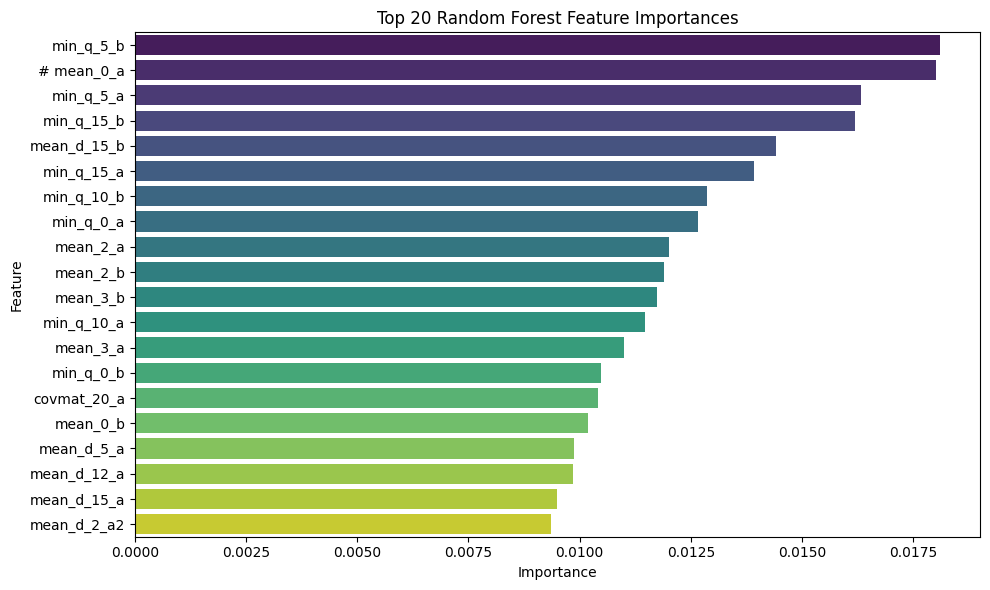

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})

# Sort by importance descending
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# Plot top 20 features
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(top_n), palette='viridis')
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**`Cross Validation`**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)
print("5-Fold CV Accuracy:", scores)
print("Mean CV Accuracy:", scores.mean())


5-Fold CV Accuracy: [0.9882904  0.97892272 0.97887324 0.98826291 0.99765258]
Mean CV Accuracy: 0.9864003694296928


**Deep Learning**

**Costum CNN**

In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Prepare EEG Features and Labels
# -----------------------------
# Assuming features_scaled_df is your preprocessed EEG DataFrame

# Features (X) → drop non-feature columns (keep only numeric EEG features)
X = features_scaled_df.drop(columns=['label'], errors='ignore').values

# Labels (y)
y = features_scaled_df['label'].values  # these are 0, 1, 2

# One-hot encode labels for deep learning
num_classes = len(np.unique(y))  # should be 3
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features (0-1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Build Deep Learning Model
# -----------------------------
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(num_classes, activation='softmax')  # 3 EEG classes
])

# -----------------------------
# 5. Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 6. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 7. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 8. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       326,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,475 (1.29 MB)

 Trainable params: 337,091 (1.29 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 107ms/step - accuracy: 0.6833 - loss: 0.8138 - val_accuracy: 0.6455 - val_loss: 2.0918
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8667 - loss: 0.3715 - val_accuracy: 0.5452 - val_loss: 3.5734
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8977 - loss: 0.2810 - val_accuracy: 0.3411 - val_loss: 5.1533
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9123 - loss: 0.2445 - val_accuracy: 0.3411 - val_loss: 5.6056
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9031 - loss: 0.2328 - val_accuracy: 0.3411 - val_loss: 7.6985
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9198 - loss: 0.2240 - val_accuracy: 0.3645 - val_loss: 6.1637
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9222 - loss: 0.1802 - val_accuracy: 0.3278 - val_loss: 8.1139
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9217 - loss: 0.1836 - val_accuracy: 0.3545 - val_lo

**Hyper parameters**

In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "dense_units": [128, 64, 32],   # units per Dense layer
    "dropout_rates": [0.3, 0.3],    # dropout after first two Dense layers
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001          # Adam optimizer learning rate
}

# -----------------------------
# 3. Prepare EEG Features and Labels
# -----------------------------
# Assuming features_scaled_df is your preprocessed EEG DataFrame

# Features (X) → drop non-feature columns (keep only numeric EEG features)
X = features_scaled_df.drop(columns=['label'], errors='ignore').values

# Labels (y)
y = features_scaled_df['label'].values  # these are 0, 1, 2

# One-hot encode labels for deep learning
num_classes = len(np.unique(y))  # should be 3
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features (0-1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 4. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 5. Build Deep Learning Model
# -----------------------------
model = Sequential()

# First Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][0], activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

# Second Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

# Third Dense layer
model.add(Dense(HYPERPARAMS["dense_units"][2], activation='relu'))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

# -----------------------------
# 6. Compile Model
# -----------------------------
optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 7. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# 8. Evaluate Model
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 9. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       326,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,475 (1.29 MB)

 Trainable params: 337,091 (1.29 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.6236 - loss: 0.8841 - val_accuracy: 0.3512 - val_loss: 2.5717
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8979 - loss: 0.3291 - val_accuracy: 0.3445 - val_loss: 5.1244
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8736 - loss: 0.3129 - val_accuracy: 0.3311 - val_loss: 5.5805
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9108 - loss: 0.2444 - val_accuracy: 0.3512 - val_loss: 5.3709
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9243 - loss: 0.2071 - val_accuracy: 0.3545 - val_loss: 5.4608
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9260 - loss: 0.2116 - val_accuracy: 0.3679 - val_loss: 5.2700
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9208 - loss: 0.1949 - val_accuracy: 0.3478 - val_loss: 5.3617
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9420 - loss: 0.1645 - val_accuracy: 0.3579 - val_l

**Validation**

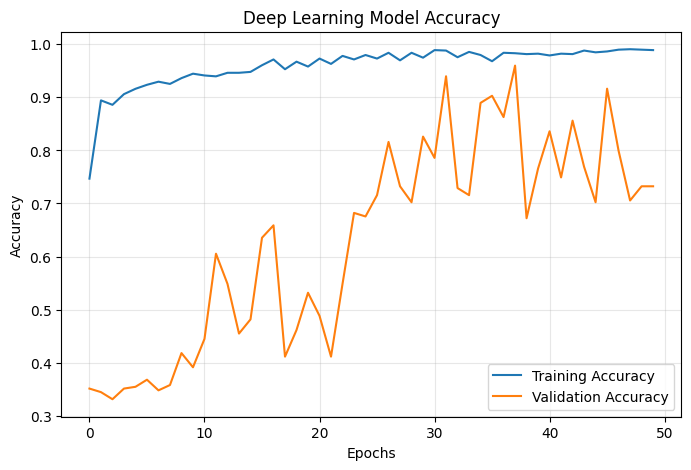

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Deep Learning Model Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**When accuracy is high **




In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "dense_units": [128, 64, 32],   # units per Dense layer
    "dropout_rates": [0.3, 0.3],    # dropout after first two Dense layers
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001,         # Adam optimizer learning rate
    "stop_val_acc": 0.99            # stop training if val_accuracy exceeds this
}

# -----------------------------
# 3. Prepare EEG Features and Labels
# -----------------------------
X = features_scaled_df.drop(columns=['label'], errors='ignore').values
y = features_scaled_df['label'].values  # these are 0, 1, 2
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 4. Build Deep Learning Model
# -----------------------------
model = Sequential()
model.add(Dense(HYPERPARAMS["dense_units"][0], activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

model.add(Dense(HYPERPARAMS["dense_units"][1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

model.add(Dense(HYPERPARAMS["dense_units"][2], activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------------
# 5. Custom Callback to Stop on Validation Accuracy
# -----------------------------
class StopOnValAccuracy(Callback):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc:
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
            if val_acc >= self.threshold:
                print(f"\nValidation accuracy {val_acc:.4f} reached threshold {self.threshold}. Stopping training.")
                self.model.stop_training = True

stop_callback = StopOnValAccuracy(threshold=HYPERPARAMS["stop_val_acc"])

# -----------------------------
# 6. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[stop_callback]
)

# Print the highest validation accuracy reached
print(f"\nHighest Validation Accuracy Achieved: {stop_callback.best_val_acc:.4f}")

# -----------------------------
# 7. Evaluate Model on Test Set
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 8. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │       326,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,475 (1.29 MB)

 Trainable params: 337,091 (1.29 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.6372 - loss: 0.8479 - val_accuracy: 0.5284 - val_loss: 1.9318
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8826 - loss: 0.3462 - val_accuracy: 0.6421 - val_loss: 2.0572
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9192 - loss: 0.2696 - val_accuracy: 0.4983 - val_loss: 2.3834
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9175 - loss: 0.2390 - val_accuracy: 0.3712 - val_loss: 3.7464
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9071 - loss: 0.2320 - val_accuracy: 0.3211 - val_loss: 7.1582
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9100 - loss: 0.2384 - val_accuracy: 0.3445 - val_loss: 7.4164
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9416 - loss: 0.1914 - val_accuracy: 0.3278 - val_loss: 7.9250
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9257 - loss: 0.1833 - val_accuracy: 0.3445 - val_lo

**LSTM**

In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 2. Hyperparameters
# -----------------------------
HYPERPARAMS = {
    "lstm_units": [128, 64],       # units per LSTM layer
    "dense_units": 32,              # units for Dense layer after LSTM
    "dropout_rates": [0.3, 0.3],   # dropout after each LSTM layer
    "batch_size": 32,
    "epochs": 50,
    "learning_rate": 0.001,
    "stop_val_acc": 0.99            # stop training if val_accuracy exceeds this
}

# -----------------------------
# 3. Prepare EEG Features and Labels
# -----------------------------
# Assuming features_scaled_df is your preprocessed EEG DataFrame

X = features_scaled_df.drop(columns=['label'], errors='ignore').values
y = features_scaled_df['label'].values  # 0, 1, 2
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# -----------------------------
# 4. Reshape for LSTM
# -----------------------------
# LSTM expects input shape: (samples, timesteps, features)
# Here we treat each feature as a "timestep" and 1 channel per timestep
X = X.reshape((X.shape[0], X.shape[1], 1))

# -----------------------------
# 5. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 6. Custom Callback to Stop on Validation Accuracy
# -----------------------------
class StopOnValAccuracy(Callback):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold
        self.best_val_acc = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc:
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
            if val_acc >= self.threshold:
                print(f"\nValidation accuracy {val_acc:.4f} reached threshold {self.threshold}. Stopping training.")
                self.model.stop_training = True

stop_callback = StopOnValAccuracy(threshold=HYPERPARAMS["stop_val_acc"])

# -----------------------------
# 7. Build LSTM Model
# -----------------------------
model = Sequential()
# First LSTM layer
model.add(LSTM(HYPERPARAMS["lstm_units"][0], return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(HYPERPARAMS["dropout_rates"][0]))

# Second LSTM layer
model.add(LSTM(HYPERPARAMS["lstm_units"][1]))
model.add(Dropout(HYPERPARAMS["dropout_rates"][1]))

# Dense layer
model.add(Dense(HYPERPARAMS["dense_units"], activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# -----------------------------
# 8. Compile Model
# -----------------------------
optimizer = Adam(learning_rate=HYPERPARAMS["learning_rate"])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# -----------------------------
# 9. Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=HYPERPARAMS["epochs"],
    batch_size=HYPERPARAMS["batch_size"],
    validation_split=0.2,
    verbose=1,
    callbacks=[stop_callback]
)

print(f"\nHighest Validation Accuracy Achieved: {stop_callback.best_val_acc:.4f}")

# -----------------------------
# 10. Evaluate Model on Test Set
# -----------------------------
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# -----------------------------
# 11. Classification Report & Confusion Matrix
# -----------------------------
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NEGATIVE', 'NEUTRAL', 'POSITIVE']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2548, 128)      │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2548, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,147 (461.51 KB)

 Trainable params: 118,147 (461.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.3123 - loss: 1.1006 - val_accuracy: 0.3278 - val_loss: 1.0997
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.3302 - loss: 1.0988 - val_accuracy: 0.3244 - val_loss: 1.0980
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.3355 - loss: 1.0993 - val_accuracy: 0.3177 - val_loss: 1.1003
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.3295 - loss: 1.1003 - val_accuracy: 0.3177 - val_loss: 1.1005
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.3251 - loss: 1.1000 - val_accuracy: 0.3177 - val_loss: 1.1005
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.3541 - loss: 1.0977 - val_accuracy: 0.3278 - val_loss: 1.0983
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.3376 - loss: 1.1004 - val_accuracy: 0.3177 - val_loss: 1.1003
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 161ms/step - accuracy: 0.3350 - loss: 1.0989 - val_accuracy: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**The end of the chapter 2**